In [1]:
from nselib import capital_market as cm
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from rich.console import Console
console = Console()

In [2]:
# =========================================================
# 2. IMPORTS
# =========================================================
import warnings
import logging
from dataclasses import dataclass
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from nselib import capital_market as cm

from rich.console import Console
from rich.table import Table

warnings.filterwarnings("ignore")
logging.getLogger("statsmodels").setLevel(logging.ERROR)
console = Console()

RANDOM_STATE = 42


In [3]:
# =========================================================
# 3. CONFIGURATION
# =========================================================

# NSE symbol, e.g. RELIANCE, TCS, INFY, SBIN, HDFCBANK
SYMBOL = "HDFCBANK"

# nselib expects dd-mm-YYYY for custom ranges.
FROM_DATE = "01-01-2021"
TO_DATE   = "18-09-2026"

# Number of future market sessions to forecast.
FORECAST_DAYS = 5

# Last percentage of observations reserved for chronological testing.
TEST_SIZE = 0.20

# Number of historical lags used by ML/NN agents.
N_LAGS = 10

# Save files
RAW_DATA_FILE = f"{SYMBOL}_NSE_raw.csv"
CLEAN_DATA_FILE = f"{SYMBOL}_NSE_clean.csv"
FORECAST_FILE = f"{SYMBOL}_multi_agent_forecast.csv"
MODEL_SCORES_FILE = f"{SYMBOL}_model_scores.csv"

print(f"Symbol: {SYMBOL}")
print(f"Date range: {FROM_DATE} → {TO_DATE}")


Symbol: HDFCBANK
Date range: 01-01-2021 → 18-09-2026


In [4]:
# =========================================================
# NSE DATA AGENT
# =========================================================
import pandas as pd
def nse_data_agent(symbol: str, from_date: str, to_date: str) -> pd.DataFrame:

    console.print(
        f"\n[bold cyan]NSE Data Agent[/bold cyan] "
        f"→ Fetching {symbol}"
    )

    # Fetch data from NSE through nselib
    raw = cm.price_volume_data(
        symbol=symbol,
        from_date=from_date,
        to_date=to_date
    )

    if raw is None or raw.empty:
        raise ValueError(
            f"No NSE data returned for {symbol} "
            f"between {from_date} and {to_date}"
        )

    # -----------------------------------------------------
    # Standardize NSE column names
    # -----------------------------------------------------

    column_mapping = {
        "symbol": "symbol",
        "series": "series",
        "date": "date",
        "prevclose": "prev_close",
        "openprice": "open",
        "highprice": "high",
        "lowprice": "low",
        "lastprice": "last",
        "closeprice": "close",
        "averageprice": "average_price",
        "totaltradedquantity": "volume",
        "turnover₹": "turnover",
        "no.oftrades": "trades"
    }

    # Convert column names to lowercase for safer matching
    raw.columns = [
        str(col).strip().lower()
        for col in raw.columns
    ]

    # Check required columns
    required_nse_columns = [
        "date",
        "openprice",
        "highprice",
        "lowprice",
        "closeprice"
    ]

    missing = [
        col for col in required_nse_columns
        if col not in raw.columns
    ]

    if missing:
        raise ValueError(
            f"NSE response is missing required columns: {missing}. "
            f"Available columns: {list(raw.columns)}"
        )

    # Rename columns
    df = raw.rename(columns=column_mapping)

    # -----------------------------------------------------
    # Data type conversion
    # -----------------------------------------------------

    df["date"] = pd.to_datetime(
        df["date"],
        errors="coerce"
    )

    numeric_columns = [
        "open",
        "high",
        "low",
        "close",
        "last",
        "average_price",
        "volume",
        "turnover",
        "trades"
    ]

    for col in numeric_columns:
        if col in df.columns:
            df[col] = pd.to_numeric(
                df[col],
                errors="coerce"
            )

    # -----------------------------------------------------
    # Clean data
    # -----------------------------------------------------

    df = df.dropna(
        subset=[
            "date",
            "open",
            "high",
            "low",
            "close"
        ]
    )

    df = df.sort_values("date")

    df = df.drop_duplicates(
        subset=["date"],
        keep="last"
    )

    df = df.set_index("date")

    console.print(
        f"[green]✓ NSE data loaded: "
        f"{len(df):,} trading sessions[/green]"
    )

    console.print(
        f"Date range: {df.index.min().date()} "
        f"→ {df.index.max().date()}"
    )

    return df

# Agent 1 output
nse_data = nse_data_agent(
    SYMBOL,
    FROM_DATE,
    TO_DATE
)

print("NSE data shape:", nse_data.shape)
display(nse_data.tail())

NSE Data Agent → Fetching HDFCBANK

✓ NSE data loaded: 254 trading sessions

Date range: 2023-07-17 → 2026-09-18

NSE data shape: (254, 12)


,symbol,series,prev_close,open,high,low,last,close,average_price,volume,turnover,trades
date,,,,,,,,,,,,
2026-09-11,HDFCBANK,EQ,693.80,683.90,709.00,681.90,708.25,708.25,693.30,NaN,NaN,NaN
2026-09-15,HDFCBANK,EQ,708.25,722.40,730.75,715.05,716.55,716.55,722.77,NaN,NaN,NaN
2026-09-16,HDFCBANK,EQ,716.55,714.90,725.40,710.85,721.50,721.50,718.56,NaN,NaN,NaN
2026-09-17,HDFCBANK,EQ,721.50,717.50,719.40,713.00,713.00,713.00,715.73,NaN,NaN,NaN
2026-09-18,HDFCBANK,EQ,713.00,715.25,733.80,715.25,731.00,731.00,728.00,NaN,NaN,NaN


In [5]:
# ============================================================
# AGENT 2 — FEATURE ENGINEERING AGENT
# ============================================================

def make_features(close_series):

    x = pd.DataFrame(index=close_series.index)

    # Target
    x["close"] = close_series

    # Lag features
    for lag in range(1, N_LAGS + 1):
        x[f"lag_{lag}"] = close_series.shift(lag)

    # Returns
    x["return_1d"] = close_series.pct_change()

    # Moving averages
    x["sma_5"] = close_series.rolling(5).mean()
    x["sma_10"] = close_series.rolling(10).mean()
    x["sma_20"] = close_series.rolling(20).mean()

    # Exponential moving averages
    x["ema_5"] = close_series.ewm(span=5, adjust=False).mean()
    x["ema_10"] = close_series.ewm(span=10, adjust=False).mean()
    x["ema_20"] = close_series.ewm(span=20, adjust=False).mean()

    # Volatility
    x["volatility_10"] = (
        close_series.pct_change().rolling(10).std()
    )

    # RSI
    delta = close_series.diff()

    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(14).mean()
    avg_loss = loss.rolling(14).mean()

    rs = avg_gain / avg_loss.replace(0, np.nan)

    x["rsi_14"] = 100 - (100 / (1 + rs))

    return x.dropna()


# Use Agent 1 output
feature_agent_output = make_features(
    nse_data["close"]
)

console.print("[bold cyan]Feature Engineering Agent[/bold cyan]")
print("Feature matrix:", feature_agent_output.shape)

display(feature_agent_output.tail())

Feature Engineering Agent

Feature matrix: (235, 20)


,close,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,return_1d,sma_5,sma_10,sma_20,ema_5,ema_10,ema_20,volatility_10,rsi_14
date,,,,,,,,,,,,,,,,,,,,
2026-09-11,708.25,693.80,687.10,703.00,710.50,712.1,706.65,700.80,711.90,709.00,720.30,0.020827,700.53,704.310,714.1050,701.790915,705.303365,713.650383,0.014010,40.572467
2026-09-15,716.55,708.25,693.80,687.10,703.00,710.5,712.10,706.65,700.80,711.90,709.00,0.011719,701.74,705.065,713.4825,706.710610,707.348207,713.926537,0.013622,45.314506
2026-09-16,721.50,716.55,708.25,693.80,687.10,703.0,710.50,712.10,706.65,700.80,711.90,0.006908,705.44,706.025,713.4075,711.640407,709.921261,714.647819,0.013719,47.654321
2026-09-17,713.00,721.50,716.55,708.25,693.80,687.1,703.00,710.50,712.10,706.65,700.80,-0.011781,710.62,707.245,713.0575,712.093604,710.481031,714.490884,0.013238,50.878735
2026-09-18,731.00,713.00,721.50,716.55,708.25,693.8,687.10,703.00,710.50,712.10,706.65,0.025245,718.06,709.680,713.3550,718.395736,714.211753,716.063181,0.015112,54.367347


In [6]:
# ============================================================
# AGENT 3 — TRAIN / TEST SPLIT
# ============================================================

# Use the output produced by Agent 2
data = feature_agent_output.copy()

# Chronological split — DO NOT shuffle time-series data
split_index = int(len(data) * (1 - TEST_SIZE))

train_df = data.iloc[:split_index].copy()
test_df = data.iloc[split_index:].copy()

console.print("[bold cyan]Train/Test Split Agent[/bold cyan]")

print(f"Total observations : {len(data)}")
print(f"Training observations : {len(train_df)}")
print(f"Testing observations  : {len(test_df)}")

print(f"\nTraining period: {train_df.index.min()} → {train_df.index.max()}")
print(f"Testing period : {test_df.index.min()} → {test_df.index.max()}")

display(train_df.tail())
display(test_df.head())

Train/Test Split Agent

Total observations : 235
Training observations : 188
Testing observations  : 47

Training period: 2025-08-28 00:00:00 → 2026-07-14 00:00:00
Testing period : 2026-07-15 00:00:00 → 2026-09-18 00:00:00


,close,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,return_1d,sma_5,sma_10,sma_20,ema_5,ema_10,ema_20,volatility_10,rsi_14
date,,,,,,,,,,,,,,,,,,,,
2026-07-08,810.30,829.30,829.85,801.05,795.90,796.15,797.95,798.90,796.30,793.20,774.65,-0.022911,813.28,804.890,790.1000,813.506001,805.639794,794.032047,0.015819,58.909370
2026-07-09,817.55,810.30,829.30,829.85,801.05,795.90,796.15,797.95,798.90,796.30,793.20,0.008947,817.61,807.325,793.6350,814.854001,807.805286,796.271852,0.014434,57.387495
2026-07-10,824.95,817.55,810.30,829.30,829.85,801.05,795.90,796.15,797.95,798.90,796.30,0.009051,822.39,810.190,797.6525,818.219334,810.922507,799.003104,0.014556,69.846154
2026-07-13,817.95,824.95,817.55,810.30,829.30,829.85,801.05,795.90,796.15,797.95,798.90,-0.008485,820.01,812.095,799.9275,818.129556,812.200233,800.807571,0.015055,63.819536
2026-07-14,809.40,817.95,824.95,817.55,810.30,829.30,829.85,801.05,795.90,796.15,797.95,-0.010453,816.03,813.240,801.5300,815.219704,811.691100,801.625897,0.015580,65.660207


,close,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,return_1d,sma_5,sma_10,sma_20,ema_5,ema_10,ema_20,volatility_10,rsi_14
date,,,,,,,,,,,,,,,,,,,,
2026-07-15,815.45,809.40,817.95,824.95,817.55,810.30,829.30,829.85,801.05,795.90,796.15,0.007475,817.06,815.170,803.0575,815.296469,812.374536,802.942478,0.015621,61.300152
2026-07-16,808.30,815.45,809.40,817.95,824.95,817.55,810.30,829.30,829.85,801.05,795.90,-0.008768,815.21,816.410,804.1175,812.964313,811.633711,803.452719,0.016015,55.853659
2026-07-17,819.60,808.30,815.45,809.40,817.95,824.95,817.55,810.30,829.30,829.85,801.05,0.013980,814.14,818.265,805.1475,815.176209,813.082127,804.990555,0.016436,59.307554
2026-07-20,777.60,819.60,808.30,815.45,809.40,817.95,824.95,817.55,810.30,829.30,829.85,-0.051245,806.07,813.040,805.0375,802.650806,806.630832,802.381931,0.019508,43.316913
2026-07-21,761.45,777.60,819.60,808.30,815.45,809.40,817.95,824.95,817.55,810.30,829.30,-0.020769,796.48,806.255,803.7900,788.917204,798.416135,798.483651,0.019894,39.585834


In [7]:
# ============================================================
# 7. METRICS
# ============================================================

def evaluate(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)

    rmse = np.sqrt(np.mean((actual - predicted) ** 2))
    mae = np.mean(np.abs(actual - predicted))

    # Avoid division by zero
    mask = actual != 0
    mape = (
        np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask]))
        * 100
    )

    return {
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape
    }

In [8]:
# =========================================================
# 9. AGENT 4 — MACHINE LEARNING FORECASTING AGENT
# =========================================================

ML_FEATURES = [
    *[f"lag_{i}" for i in range(1, N_LAGS + 1)],
    "return_1",
    "return_5",
    "sma_5",
    "sma_10",
    "sma_20",
    "ema_10",
    "ema_20",
    "volatility_10",
    "rsi_14",
]


def latest_feature_row(history: pd.Series) -> pd.DataFrame:
    """Generate one prediction row from the latest known/forecast history."""
    f = make_features(history, N_LAGS)
    return f[ML_FEATURES].tail(1)


def ml_recursive_forecast(
    history: pd.Series,
    horizon: int,
    model
) -> np.ndarray:
    train_features = make_features(history, N_LAGS)
    X_train = train_features[ML_FEATURES]
    y_train = train_features["target"]

    model.fit(X_train, y_train)

    extended = history.copy()
    predictions = []

    for _ in range(horizon):
        x_next = latest_feature_row(extended)[ML_FEATURES]
        pred = float(model.predict(x_next)[0])
        predictions.append(pred)

        next_index = extended.index[-1] + pd.offsets.BDay(1)
        extended.loc[next_index] = pred

    return np.asarray(predictions)


def machine_learning_agent(train: pd.Series, test: pd.Series):
    console.print(
        "[bold yellow]Machine Learning Agent → "
        "Random Forest + Gradient Boosting[/bold yellow]"
    )

    models = {
        "RandomForest": RandomForestRegressor(
            n_estimators=300,
            max_depth=8,
            min_samples_leaf=3,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "GradientBoosting": GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.03,
            max_depth=3,
            loss="huber",
            random_state=RANDOM_STATE,
        ),
    }

    outputs = {}
    for name, model in models.items():
        pred = ml_recursive_forecast(train, len(test), model)
        outputs[name] = {
            "name": name,
            "pred": pred,
            "metrics": evaluate(test.values, pred),
            "model": model,
        }

    return outputs


In [9]:
# =========================================================
# 10. AGENT 5 — NEURAL NETWORK FORECASTING AGENT
# =========================================================

def neural_network_agent(train: pd.Series, test: pd.Series):
    console.print("[bold yellow]Neural Network Agent → MLPRegressor[/bold yellow]")

    model = make_pipeline(
        StandardScaler(),
        MLPRegressor(
            hidden_layer_sizes=(64, 32),
            activation="relu",
            solver="adam",
            alpha=0.0005,
            learning_rate_init=0.001,
            max_iter=800,
            early_stopping=True,
            random_state=RANDOM_STATE,
        )
    )

    pred = ml_recursive_forecast(train, len(test), model)

    return {
        "name": "MLP",
        "pred": pred,
        "metrics": evaluate(test.values, pred),
        "model": model,
    }


In [10]:
def fit_full_and_forecast(model_name, history, horizon):

    # Make sure history is numeric
    history = pd.Series(
        history.values,
        dtype="float64"
    )

    # ========================================
    # ARIMA
    # ========================================

    if model_name == "ARIMA":

        model = ARIMA(
            history.values,
            order=(5, 1, 0)
        )

        fitted_model = model.fit()

        forecast = fitted_model.forecast(
            steps=horizon
        )

        return np.asarray(forecast, dtype=float)


    # ========================================
    # Machine Learning Models
    # ========================================

    if model_name in [
        "Random Forest",
        "Gradient Boosting",
        "MLP"
    ]:

        values = history.values

        X = []
        y = []

        for i in range(N_LAGS, len(values)):

            X.append(
                values[i-N_LAGS:i][::-1]
            )

            y.append(values[i])

        X = np.asarray(X)
        y = np.asarray(y)


        # ------------------------------------
        # Random Forest
        # ------------------------------------

        if model_name == "Random Forest":

            model = RandomForestRegressor(
                n_estimators=300,
                random_state=42,
                n_jobs=-1
            )


        # ------------------------------------
        # Gradient Boosting
        # ------------------------------------

        elif model_name == "Gradient Boosting":

            model = GradientBoostingRegressor(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=3,
                random_state=42
            )


        # ------------------------------------
        # MLP
        # ------------------------------------

        else:

            model = make_pipeline(
                StandardScaler(),
                MLPRegressor(
                    hidden_layer_sizes=(64, 32),
                    activation="relu",
                    max_iter=500,
                    random_state=42
                )
            )


        # Train model
        model.fit(X, y)

        # Recursive forecast
        return ml_recursive_forecast(
            history,
            horizon,
            model
        )


    raise ValueError(
        f"Unknown model: {model_name}"
    )

In [11]:
def ml_recursive_forecast(history, horizon, model):

    # Convert history to numeric values only
    values = np.asarray(history, dtype=float).copy()

    predictions = []

    for _ in range(horizon):

        # Use the same feature structure used during model training
        X_next = values[-N_LAGS:][::-1].reshape(1, -1)

        # Predict next closing price
        prediction = model.predict(X_next)[0]

        predictions.append(float(prediction))

        # Add prediction to history
        values = np.append(values, prediction)

    return np.asarray(predictions, dtype=float)

In [12]:
model_predictions = {}

forecast_history = train_df["close"]
forecast_horizon = len(test_df)

print("Generating model predictions...")

model_predictions["ARIMA"] = fit_full_and_forecast(
    "ARIMA",
    forecast_history,
    forecast_horizon
)

model_predictions["Random Forest"] = fit_full_and_forecast(
    "Random Forest",
    forecast_history,
    forecast_horizon
)

model_predictions["Gradient Boosting"] = fit_full_and_forecast(
    "Gradient Boosting",
    forecast_history,
    forecast_horizon
)

model_predictions["MLP"] = fit_full_and_forecast(
    "MLP",
    forecast_history,
    forecast_horizon
)

print("\nModel Predictions Generated:")

for model_name, predictions in model_predictions.items():
    print(
        f"{model_name:20s} → "
     
        f"{len(predictions)} predictions"
    )

Generating model predictions...

Model Predictions Generated:
ARIMA                → 47 predictions
Random Forest        → 47 predictions
Gradient Boosting    → 47 predictions
MLP                  → 47 predictions


In [13]:
model_predictions = {}

forecast_history = train_df["close"]
forecast_horizon = len(test_df)

print("Generating model predictions...")

model_predictions["ARIMA"] = fit_full_and_forecast(
    "ARIMA",
    forecast_history,
    forecast_horizon
)

model_predictions["Random Forest"] = fit_full_and_forecast(
    "Random Forest",
    forecast_history,
    forecast_horizon
)

model_predictions["Gradient Boosting"] = fit_full_and_forecast(
    "Gradient Boosting",
    forecast_history,
    forecast_horizon
)

model_predictions["MLP"] = fit_full_and_forecast(
    "MLP",
    forecast_history,
    forecast_horizon
)

print("\nModel Predictions Generated:")

for model_name, predictions in model_predictions.items():
    print(
        f"{model_name:20s} → "
        f"{len(predictions)} predictions"
    )

Generating model predictions...

Model Predictions Generated:
ARIMA                → 47 predictions
Random Forest        → 47 predictions
Gradient Boosting    → 47 predictions
MLP                  → 47 predictions


In [14]:
# ============================================================
# VALIDATION AGENT
# ============================================================

def validation_agent(train_df, test_df, model_predictions):
    """
    Validate forecasting models using the NSE test dataset.

    Parameters
    ----------
    train_df : pd.DataFrame
        Training dataset.
    test_df : pd.DataFrame
        Holdout/test dataset containing actual close prices.
    model_predictions : dict
        Dictionary containing predictions from each forecasting agent.

    Returns
    -------
    validation_results : dict
        RMSE, MAE and MAPE for each model.
    """

    console.print("\n[bold cyan]Validation Agent[/bold cyan]")

    # Actual NSE closing prices
    actual_close = test_df["close"].values

    validation_results = {}

    for model_name, predicted in model_predictions.items():

        # Convert prediction to numpy array
        predicted = np.asarray(predicted, dtype=float)

        # Make sure actual and predicted lengths match
        n = min(len(actual_close), len(predicted))

        actual = actual_close[:n]
        pred = predicted[:n]

        # Calculate metrics
        metrics = evaluate(actual, pred)

        validation_results[model_name] = metrics

        print(
            f"{model_name:20s} | "
            f"RMSE: {metrics['RMSE']:.4f} | "
            f"MAE: {metrics['MAE']:.4f} | "
            f"MAPE: {metrics['MAPE']:.2f}%"
        )

    return validation_results

validation_results = validation_agent(
    train_df,
    test_df,
    model_predictions
)

Validation Agent

ARIMA                | RMSE: 81.9136 | MAE: 77.7794 | MAPE: 10.75%
Random Forest        | RMSE: 78.7045 | MAE: 74.6284 | MAPE: 10.32%
Gradient Boosting    | RMSE: 82.6314 | MAE: 78.4467 | MAPE: 10.84%
MLP                  | RMSE: 83.5178 | MAE: 66.6954 | MAPE: 9.08%


In [15]:
print("model_predictions exists:",
      "model_predictions" in globals())

print("validation_results exists:",
      "validation_results" in globals())

model_predictions exists: True
validation_results exists: True


In [16]:
validation_results = validation_agent(
    train_df,
    test_df,
    model_predictions
)

Validation Agent

ARIMA                | RMSE: 81.9136 | MAE: 77.7794 | MAPE: 10.75%
Random Forest        | RMSE: 78.7045 | MAE: 74.6284 | MAPE: 10.32%
Gradient Boosting    | RMSE: 82.6314 | MAE: 78.4467 | MAPE: 10.84%
MLP                  | RMSE: 83.5178 | MAE: 66.6954 | MAPE: 9.08%


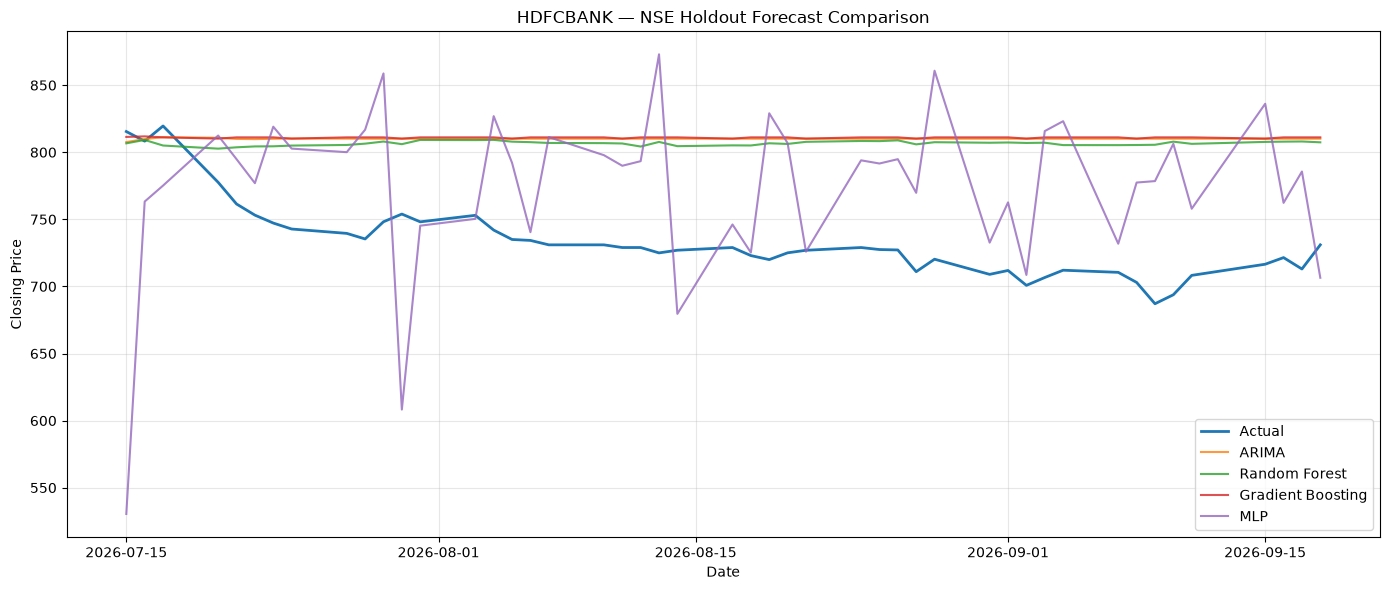

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    test_df.index,
    test_df["close"].values,
    label="Actual",
    linewidth=2
)

for name, predictions in model_predictions.items():

    predictions = np.asarray(predictions, dtype=float)

    n = min(len(test_df), len(predictions))

    plt.plot(
        test_df.index[:n],
        predictions[:n],
        label=name,
        alpha=0.8
    )

plt.title(
    f"{SYMBOL} — NSE Holdout Forecast Comparison"
)

plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
print("nse_data:", "nse_data" in globals())
print("feature_agent_output:", "feature_agent_output" in globals())
print("train_df:", "train_df" in globals())
print("test_df:", "test_df" in globals())

nse_data: True
feature_agent_output: True
train_df: True
test_df: True


In [19]:
# ============================================================
# FORECASTING AGENTS
# ============================================================

import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

console.print("\n[bold cyan]Forecasting Agents[/bold cyan]")

model_predictions = {}

# ------------------------------------------------------------
# AGENT 3A — ARIMA
# ------------------------------------------------------------

try:
    arima_model = ARIMA(
        train_df["close"],
        order=(5, 1, 0)
    )

    arima_fit = arima_model.fit()

    arima_pred = arima_fit.forecast(
        steps=len(test_df)
    )

    model_predictions["ARIMA"] = np.asarray(arima_pred)

    print("✓ ARIMA predictions generated")

except Exception as e:
    print(f"✗ ARIMA failed: {e}")


# ------------------------------------------------------------
# Prepare ML features
# ------------------------------------------------------------

feature_columns = [
    col for col in train_df.columns
    if col != "close"
]

X_train = train_df[feature_columns]
y_train = train_df["close"]

X_test = test_df[feature_columns]


# ------------------------------------------------------------
# AGENT 3B — Random Forest
# ------------------------------------------------------------

try:

    rf_model = RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )

    rf_model.fit(X_train, y_train)

    rf_pred = rf_model.predict(X_test)

    model_predictions["Random Forest"] = rf_pred

    print("✓ Random Forest predictions generated")

except Exception as e:
    print(f"✗ Random Forest failed: {e}")


# ------------------------------------------------------------
# AGENT 3C — Gradient Boosting
# ------------------------------------------------------------

try:

    gb_model = GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

    gb_model.fit(X_train, y_train)

    gb_pred = gb_model.predict(X_test)

    model_predictions["Gradient Boosting"] = gb_pred

    print("✓ Gradient Boosting predictions generated")

except Exception as e:
    print(f"✗ Gradient Boosting failed: {e}")


# ------------------------------------------------------------
# AGENT 3D — Neural Network / MLP
# ------------------------------------------------------------

try:

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    mlp_model = MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        max_iter=500,
        random_state=42
    )

    mlp_model.fit(
        X_train_scaled,
        y_train
    )

    mlp_pred = mlp_model.predict(X_test_scaled)

    model_predictions["MLP"] = mlp_pred

    print("✓ MLP predictions generated")

except Exception as e:
    print(f"✗ MLP failed: {e}")



   
# ------------------------------------------------------------
# Check results
# ------------------------------------------------------------

print("\nModels successfully generated:")

for name, pred in model_predictions.items():
    print(
        f"{name:20s} → "
        f"{len(pred)} predictions"
    )

Forecasting Agents

✗ ARIMA failed: No supported index is available.
✓ Random Forest predictions generated
✓ Gradient Boosting predictions generated
✓ MLP predictions generated

Models successfully generated:
Random Forest        → 47 predictions
Gradient Boosting    → 47 predictions
MLP                  → 47 predictions


In [20]:
print("model_predictions exists:",
      "model_predictions" in globals())

print("\nAvailable models:")

for name, pred in model_predictions.items():
    print(name, len(pred))

model_predictions exists: True

Available models:
Random Forest 47
Gradient Boosting 47
MLP 47


In [21]:
# ============================================================
# VALIDATION AGENT
# ============================================================

def validation_agent(train_df, test_df, model_predictions):
    """
    Validate forecasting models using the NSE test dataset.

    Parameters
    ----------
    train_df : pd.DataFrame
        Training dataset.
    test_df : pd.DataFrame
        Holdout/test dataset containing actual close prices.
    model_predictions : dict
        Dictionary containing predictions from each forecasting agent.

    Returns
    -------
    validation_results : dict
        RMSE, MAE and MAPE for each model.
    """

    console.print("\n[bold cyan]Validation Agent[/bold cyan]")

    # Actual NSE closing prices
    actual_close = test_df["close"].values

    validation_results = {}

    for model_name, predicted in model_predictions.items():

        # Convert prediction to numpy array
        predicted = np.asarray(predicted, dtype=float)

        # Make sure actual and predicted lengths match
        n = min(len(actual_close), len(predicted))

        actual = actual_close[:n]
        pred = predicted[:n]

        # Calculate metrics
        metrics = evaluate(actual, pred)

        validation_results[model_name] = metrics

        print(
            f"{model_name:20s} | "
            f"RMSE: {metrics['RMSE']:.4f} | "
            f"MAE: {metrics['MAE']:.4f} | "
            f"MAPE: {metrics['MAPE']:.2f}%"
        )

    return validation_results

In [22]:
# ============================================================
# CREATE MODEL SCORECARD
# ============================================================

scores = pd.DataFrame([
    {
        "Model": model,
        "RMSE": metrics["RMSE"],
        "MAE": metrics["MAE"],
        "MAPE": metrics["MAPE"]
    }
    for model, metrics in validation_results.items()
])

# Sort by RMSE
scores = scores.sort_values(
    by=["RMSE", "MAE"],
    ascending=[True, True]
).reset_index(drop=True)

console.print("\n[bold cyan]Model Scorecard[/bold cyan]")

display(scores)

Model Scorecard

,Model,RMSE,MAE,MAPE
0,Random Forest,78.704495,74.628379,10.316249
1,ARIMA,81.913602,77.779413,10.750840
2,Gradient Boosting,82.631403,78.446744,10.843374
3,MLP,83.517784,66.695434,9.079105


In [23]:
validation_results = validation_agent(
    train_df,
    test_df,
    model_predictions
)

Validation Agent

Random Forest        | RMSE: 27.9244 | MAE: 23.3053 | MAPE: 3.24%
Gradient Boosting    | RMSE: 28.4271 | MAE: 22.5569 | MAPE: 3.15%
MLP                  | RMSE: 368.1179 | MAE: 332.9968 | MAPE: 45.93%


In [24]:

print(validation_results)

{'Random Forest': {'RMSE': np.float64(27.92435532466125), 'MAE': np.float64(23.30526241134858), 'MAPE': np.float64(3.243679846485987)}, 'Gradient Boosting': {'RMSE': np.float64(28.42713373485662), 'MAE': np.float64(22.55693479922206), 'MAPE': np.float64(3.1460852444948118)}, 'MLP': {'RMSE': np.float64(368.1178951574394), 'MAE': np.float64(332.99679797437113), 'MAPE': np.float64(45.92746856764008)}}


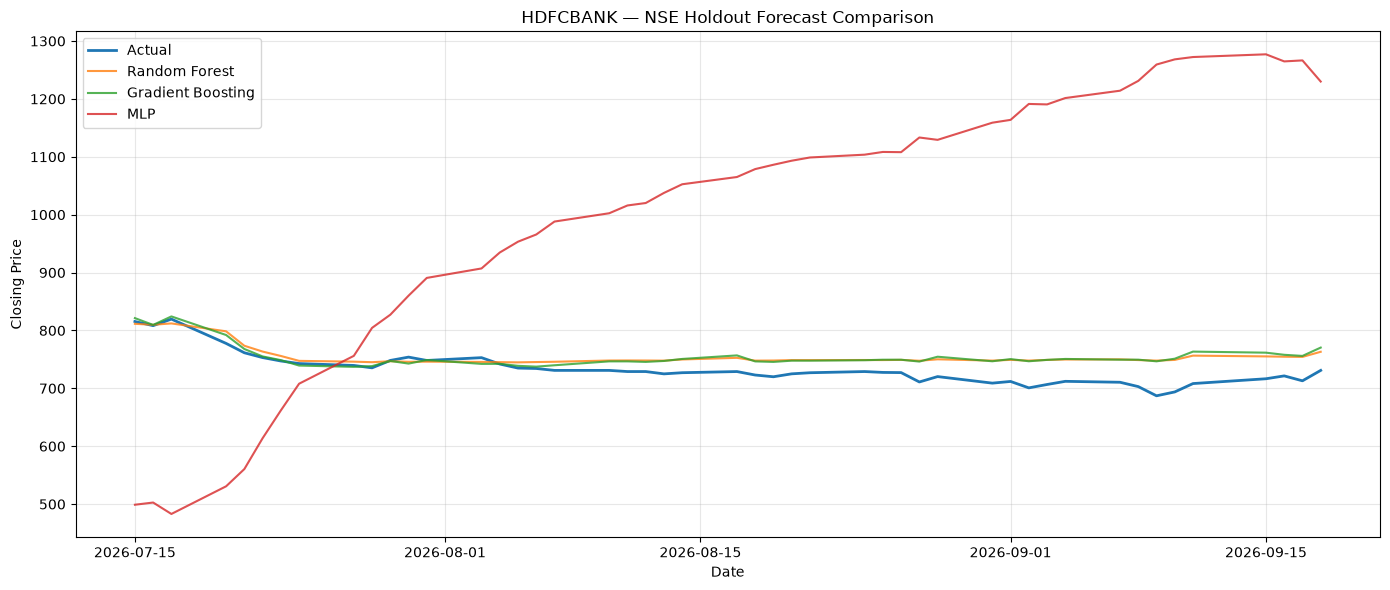

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    test_df.index,
    test_df["close"].values,
    label="Actual",
    linewidth=2
)

for name, predictions in model_predictions.items():

    predictions = np.asarray(predictions, dtype=float)

    n = min(len(test_df), len(predictions))

    plt.plot(
        test_df.index[:n],
        predictions[:n],
        label=name,
        alpha=0.8
    )

plt.title(
    f"{SYMBOL} — NSE Holdout Forecast Comparison"
)

plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
# ============================================================
# DECISION AGENT
# ============================================================

def decision_agent(results, scores: pd.DataFrame):

    console.print(
        "[bold magenta]Decision Agent Running[/bold magenta]"
    )

    # Rank primarily by RMSE,
    # with MAE as a secondary signal.

    ranked_scores = scores.sort_values(
        by=["RMSE", "MAE"],
        ascending=[True, True]
    ).reset_index(drop=True)

    best_model = ranked_scores.iloc[0]["Model"]

    print("\nModel Ranking:")
    display(ranked_scores)

    print(f"\n🏆 Best Model: {best_model}")

    return best_model, ranked_scores

In [27]:
def final_forecast_agent(history, best_model, horizon):

    console.print(
        "[bold red]Final Forecast Agent Running[/bold red]"
    )

    # Forecast using the selected best model
    forecast = fit_full_and_forecast(
        best_model,
        history,
        horizon
    )

    # Create forecast dates
    last_date = history.index[-1]

    forecast_dates = pd.bdate_range(
        start=last_date + pd.Timedelta(days=1),
        periods=horizon
    )

    forecast_df = pd.DataFrame({
        "Date": forecast_dates,
        "Forecast": forecast
    })

    forecast_df.set_index("Date", inplace=True)

    print(f"\n🏆 Selected Model: {best_model}")
    print(f"📈 Forecast Horizon: {horizon} trading days")

    display(forecast_df)

    return forecast_df

In [28]:
print("validation_results:", "validation_results" in globals())
print("scores:", "scores" in globals())
print("best_model:", "best_model" in globals())

validation_results: True
scores: True
best_model: False


In [29]:
# ============================================================
# DECISION AGENT
# ============================================================

def decision_agent(results, scores):

    console.print(
        "[bold magenta]Decision Agent Running[/bold magenta]"
    )

    # Rank models by RMSE, then MAE
    ranked_scores = scores.sort_values(
        by=["RMSE", "MAE"],
        ascending=[True, True]
    ).reset_index(drop=True)

    # Select best-performing model
    best_model = ranked_scores.iloc[0]["Model"]

    print("\nModel Ranking:")
    display(ranked_scores)

    print(f"\n🏆 Best Model: {best_model}")

    return best_model, ranked_scores

In [30]:
best_model, ranked_scores = decision_agent(
    validation_results,
   scores
)

Decision Agent Running


Model Ranking:


,Model,RMSE,MAE,MAPE
0,Random Forest,78.704495,74.628379,10.316249
1,ARIMA,81.913602,77.779413,10.750840
2,Gradient Boosting,82.631403,78.446744,10.843374
3,MLP,83.517784,66.695434,9.079105



🏆 Best Model: Random Forest


In [31]:
print("Best model:", best_model)
print("\nRanked models:")
display(ranked_scores)

Best model: Random Forest

Ranked models:


,Model,RMSE,MAE,MAPE
0,Random Forest,78.704495,74.628379,10.316249
1,ARIMA,81.913602,77.779413,10.750840
2,Gradient Boosting,82.631403,78.446744,10.843374
3,MLP,83.517784,66.695434,9.079105


In [32]:
def final_forecast_agent(history, best_model, horizon):

    console.print(
        "[bold red]Final Forecast Agent Running[/bold red]"
    )

    forecast = fit_full_and_forecast(
        best_model,
        history,
        horizon
    )

    last_date = history.index[-1]

    forecast_dates = pd.bdate_range(
        start=last_date + pd.Timedelta(days=1),
        periods=horizon
    )

    forecast_df = pd.DataFrame({
        "Date": forecast_dates,
        "Forecast": forecast
    })

    forecast_df.set_index("Date", inplace=True)

    print(f"\n🏆 Selected Model: {best_model}")
    print(f"📈 Forecast Horizon: {horizon} trading days")

    display(forecast_df)

    return forecast_df, forecast

In [33]:
forecast_df, forecast_matrix = final_forecast_agent(
    nse_data["close"],
    best_model,
    FORECAST_DAYS
)

console.print(
    "\n[bold green]Final Forecast Generated[/bold green]"
)

display(forecast_df)

Final Forecast Agent Running


🏆 Selected Model: Random Forest
📈 Forecast Horizon: 5 trading days


,Forecast
Date,
2026-09-21,712.618667
2026-09-22,719.946500
2026-09-23,712.174833
2026-09-24,715.643167
2026-09-25,711.429333


Final Forecast Generated

,Forecast
Date,
2026-09-21,712.618667
2026-09-22,719.946500
2026-09-23,712.174833
2026-09-24,715.643167
2026-09-25,711.429333
